# PrivateBoost — Paper Figures

Generate all figures and results for the paper:
1. **Learning curves** — privateboost vs XGBoost on 3 medical datasets
2. **Split gain retention** — histogram binning vs exact splits
3. **Dropout resilience** — accuracy under client dropout

Uses 5 stratified random splits for statistical validity. Results are saved as PNGs and CSVs in `../paper/figures/`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.datasets import load_breast_cancer, fetch_openml
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedShuffleSplit
from pathlib import Path

from privateboost import Client, ShareHolder, Aggregator

%matplotlib inline
plt.rcParams.update({"font.size": 14})

OUTPUT_DIR = Path("../paper/figures")
OUTPUT_DIR.mkdir(exist_ok=True)

## Hyperparameters

In [2]:
N_TREES = 15
MAX_DEPTH = 3
LEARNING_RATE = 0.15
LAMBDA_REG = 2.0
N_BINS = 10
N_SHAREHOLDERS = 3
THRESHOLD = 2
MIN_CLIENTS = 10
BIN_RANGE_STDS = 3

N_SPLITS = 5
SEED = 42

## Load datasets

In [3]:
HEART_FEATURES = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal",
]

datasets = {}

# Heart Disease (UCI)
print("Loading Heart Disease...")
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
df = pd.read_csv(url, names=[*HEART_FEATURES, "target"], na_values="?").dropna()
df["target"] = (df["target"] > 0).astype(int)
datasets["Heart Disease"] = {"X": df[HEART_FEATURES].values.astype(float), "y": df["target"].values}
print(f"  {len(df)} samples, {len(HEART_FEATURES)} features")

# Breast Cancer (sklearn)
print("Loading Breast Cancer...")
data = load_breast_cancer()
datasets["Breast Cancer"] = {"X": data.data, "y": data.target}
print(f"  {len(data.data)} samples, {data.data.shape[1]} features")

# Pima Diabetes (OpenML)
print("Loading Pima Diabetes...")
diabetes = fetch_openml(name="diabetes", version=1, as_frame=False)
datasets["Pima Diabetes"] = {"X": diabetes.data, "y": (diabetes.target == "tested_positive").astype(int)}
print(f"  {len(diabetes.data)} samples, {diabetes.data.shape[1]} features")

Loading Heart Disease...


  297 samples, 13 features
Loading Breast Cancer...
  569 samples, 30 features
Loading Pima Diabetes...
  768 samples, 8 features


## Training helpers

In [4]:
def train_privateboost(X_train, y_train, X_test, y_test):
    """Train privateboost and return per-tree test accuracy history."""
    shs = [ShareHolder(party_id=i, x_coord=i + 1, min_clients=MIN_CLIENTS) for i in range(N_SHAREHOLDERS)]
    agg = Aggregator(shs, n_bins=N_BINS, threshold=THRESHOLD, min_clients=MIN_CLIENTS,
                     learning_rate=LEARNING_RATE, lambda_reg=LAMBDA_REG)
    clients = [Client(f"c_{i}", X_train[i], float(y_train[i]), shs, threshold=THRESHOLD, seed=SEED + i)
               for i in range(len(X_train))]

    for c in clients:
        c.submit_stats()
    bins = agg.define_bins()

    history = []
    for round_id in range(N_TREES):
        for depth in range(MAX_DEPTH):
            for c in clients:
                c.submit_gradients(bins, agg.model, agg.splits, round_id=round_id, depth=depth, loss="logistic")
            if not agg.compute_splits(depth=depth, min_child_weight=1.0):
                break
        agg.finish_round()
        te_p = agg.model.predict(X_test)
        history.append(accuracy_score(y_test, (te_p >= 0.5).astype(int)))

    return history


def train_xgboost(X_train, y_train, X_test, y_test, matched=True, seed=SEED):
    """Train XGBoost and return per-tree test accuracy history."""
    history = []
    for n in range(1, N_TREES + 1):
        if matched:
            model = xgb.XGBClassifier(n_estimators=n, max_depth=MAX_DEPTH, learning_rate=LEARNING_RATE,
                                       reg_lambda=LAMBDA_REG, tree_method="hist", max_bin=N_BINS, random_state=seed)
        else:
            model = xgb.XGBClassifier(n_estimators=n, random_state=seed)
        model.fit(X_train, y_train, verbose=False)
        history.append(accuracy_score(y_test, model.predict(X_test)))
    return history


def train_with_dropout(X_train, y_train, X_test, y_test, dropout_rate, seed=42):
    """Train privateboost with client dropout. Returns final accuracy or None."""
    rng = np.random.default_rng(seed)
    shs = [ShareHolder(party_id=i, x_coord=i + 1, min_clients=MIN_CLIENTS) for i in range(N_SHAREHOLDERS)]
    agg = Aggregator(shs, n_bins=N_BINS, threshold=THRESHOLD, min_clients=MIN_CLIENTS,
                     learning_rate=LEARNING_RATE, lambda_reg=LAMBDA_REG)
    clients = [Client(f"c_{i}", X_train[i], float(y_train[i]), shs, threshold=THRESHOLD, seed=seed + i)
               for i in range(len(X_train))]

    for c in clients:
        c.submit_stats()

    try:
        bins = agg.define_bins()
    except ValueError:
        return None

    try:
        for round_id in range(N_TREES):
            round_mask = rng.random(len(clients)) >= dropout_rate
            round_clients = [c for c, active in zip(clients, round_mask) if active]
            for depth in range(MAX_DEPTH):
                for c in round_clients:
                    c.submit_gradients(bins, agg.model, agg.splits, round_id=round_id, depth=depth, loss="logistic")
                if not agg.compute_splits(depth=depth, min_child_weight=1.0):
                    break
            agg.finish_round()
    except ValueError:
        return None

    test_preds = agg.model.predict(X_test)
    return accuracy_score(y_test, (test_preds >= 0.5).astype(int))

## Figure 1: Learning Curves

Train privateboost, XGBoost (matched hyperparameters), and XGBoost (defaults) on all 3 datasets with 5 stratified random splits. Plot mean accuracy +/- std as a function of number of trees.

In [5]:
learning_results = {}

for name, data in datasets.items():
    print(f"{name}...")
    splitter = StratifiedShuffleSplit(n_splits=N_SPLITS, test_size=0.2, random_state=SEED)
    pb_runs, xgb_matched_runs, xgb_default_runs = [], [], []

    for fold, (train_idx, test_idx) in enumerate(splitter.split(data["X"], data["y"])):
        X_train, y_train = data["X"][train_idx], data["y"][train_idx]
        X_test, y_test = data["X"][test_idx], data["y"][test_idx]
        print(f"  split {fold + 1}/{N_SPLITS}")

        pb_runs.append(train_privateboost(X_train, y_train, X_test, y_test))
        xgb_matched_runs.append(train_xgboost(X_train, y_train, X_test, y_test, matched=True, seed=SEED + fold))
        xgb_default_runs.append(train_xgboost(X_train, y_train, X_test, y_test, matched=False, seed=SEED + fold))

    learning_results[name] = {
        "privateboost": np.array(pb_runs),
        "xgboost_matched": np.array(xgb_matched_runs),
        "xgboost_default": np.array(xgb_default_runs),
    }

Heart Disease...
  split 1/5


  split 2/5


  split 3/5


  split 4/5


  split 5/5


...

Pima Diabetes...
  split 1/5


  split 2/5


  split 3/5


  split 4/5


  split 5/5


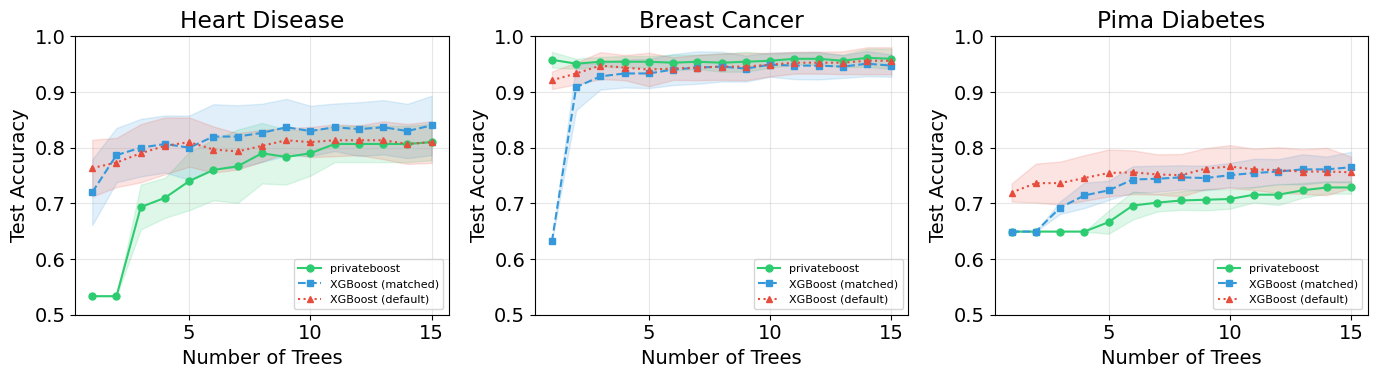

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
trees = np.arange(1, N_TREES + 1)

for ax, name in zip(axes, learning_results.keys()):
    for key, color, marker, ls, label in [
        ("privateboost", "#2ecc71", "o", "-", "privateboost"),
        ("xgboost_matched", "#3498db", "s", "--", "XGBoost (matched)"),
        ("xgboost_default", "#e74c3c", "^", ":", "XGBoost (default)"),
    ]:
        runs = learning_results[name][key]
        mean = runs.mean(axis=0)
        std = runs.std(axis=0)
        ax.plot(trees, mean, f"{marker}{ls}", color=color, label=label, markersize=5)
        ax.fill_between(trees, mean - std, mean + std, color=color, alpha=0.15)

    ax.set_xlabel("Number of Trees")
    ax.set_ylabel("Test Accuracy")
    ax.set_title(name)
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_ylim(0.5, 1.0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### Accuracy summary table

In [7]:
rows = []
for name, res in learning_results.items():
    row = {"Dataset": name}
    for key, label in [("privateboost", "privateboost"), ("xgboost_matched", "XGBoost (matched)"), ("xgboost_default", "XGBoost (default)")]:
        finals = res[key][:, -1]
        row[label] = f"{finals.mean():.1%} ± {finals.std():.1%}"
    rows.append(row)

df_acc = pd.DataFrame(rows).set_index("Dataset")
df_acc

,privateboost,XGBoost (matched),XGBoost (default)
Dataset,,,
Heart Disease,81.0% ± 3.3%,84.0% ± 5.3%,81.0% ± 3.7%
Breast Cancer,96.0% ± 1.8%,94.7% ± 2.0%,95.6% ± 2.4%
Pima Diabetes,72.9% ± 1.1%,76.5% ± 2.8%,75.6% ± 2.8%


## Figure 2: Split Gain Retention

For each feature in the Heart Disease dataset, compare the best XGBoost split gain achievable with exact thresholds vs. privateboost's equal-width histogram bins. Retention = hist_gain / exact_gain.

In [8]:
def xgb_gain(g_left, h_left, g_right, h_right, lambda_reg):
    total_g = g_left + g_right
    total_h = h_left + h_right
    return 0.5 * (g_left**2 / (h_left + lambda_reg) + g_right**2 / (h_right + lambda_reg)
                  - total_g**2 / (total_h + lambda_reg))


def best_gain_exact(values, gradients, hessians, lambda_reg):
    order = np.argsort(values)
    sorted_v, sorted_g, sorted_h = values[order], gradients[order], hessians[order]
    total_g, total_h = sorted_g.sum(), sorted_h.sum()
    best, cum_g, cum_h = 0.0, 0.0, 0.0
    for i in range(len(sorted_v) - 1):
        cum_g += sorted_g[i]
        cum_h += sorted_h[i]
        if sorted_v[i] == sorted_v[i + 1]:
            continue
        gain = xgb_gain(cum_g, cum_h, total_g - cum_g, total_h - cum_h, lambda_reg)
        best = max(best, gain)
    return best


def best_gain_histogram(values, gradients, hessians, mean, std, n_bins, lambda_reg):
    inner_edges = np.linspace(mean - BIN_RANGE_STDS * std, mean + BIN_RANGE_STDS * std, n_bins + 1)
    edges = np.concatenate([[-np.inf], inner_edges, [np.inf]])
    n_total_bins = n_bins + 2
    bin_g, bin_h = np.zeros(n_total_bins), np.zeros(n_total_bins)
    for i in range(len(values)):
        idx = min(max(int(np.searchsorted(edges, values[i], side="right")) - 1, 0), n_total_bins - 1)
        bin_g[idx] += gradients[i]
        bin_h[idx] += hessians[i]
    total_g, total_h = bin_g.sum(), bin_h.sum()
    best, cum_g, cum_h = 0.0, 0.0, 0.0
    for i in range(n_total_bins - 1):
        cum_g += bin_g[i]
        cum_h += bin_h[i]
        best = max(best, xgb_gain(cum_g, cum_h, total_g - cum_g, total_h - cum_h, lambda_reg))
    return best

In [9]:
# Compute gain retention on Heart Disease
hd = datasets["Heart Disease"]
X, y = hd["X"], hd["y"].astype(float)

# Initial prediction = log-odds of target mean
p = np.clip(y.mean(), 1e-7, 1 - 1e-7)
init_pred = np.log(p / (1 - p))
prob = 1.0 / (1.0 + np.exp(-init_pred))
gradients = np.full(len(y), prob) - y
hessians = np.full(len(y), prob * (1 - prob))

retentions = []
for f_idx, fname in enumerate(HEART_FEATURES):
    values = X[:, f_idx]
    exact = best_gain_exact(values, gradients, hessians, LAMBDA_REG)
    hist = best_gain_histogram(values, gradients, hessians, values.mean(), values.std(), N_BINS, LAMBDA_REG)
    retention = (hist / exact * 100) if exact > 0 else 100.0
    retentions.append(retention)
    print(f"  {fname:>10s}: exact={exact:.6f}  hist={hist:.6f}  retention={retention:.1f}%")

print(f"\n  Mean retention: {np.mean(retentions):.1f}%")

         age: exact=12.110481  hist=12.110481  retention=100.0%
         sex: exact=10.769131  hist=10.769131  retention=100.0%
          cp: exact=36.207370  hist=36.207370  retention=100.0%
    trestbps: exact=2.927395  hist=2.927395  retention=100.0%
        chol: exact=3.247300  hist=2.980193  retention=91.8%
         fbs: exact=0.001282  hist=0.001282  retention=100.0%
     restecg: exact=4.217277  hist=4.217277  retention=100.0%
     thalach: exact=24.999594  hist=21.200744  retention=84.8%
       exang: exact=24.671430  hist=24.671430  retention=100.0%
     oldpeak: exact=22.232290  hist=22.232290  retention=100.0%
       slope: exact=20.398133  hist=20.398133  retention=100.0%
          ca: exact=32.834627  hist=32.834627  retention=100.0%
        thal: exact=38.779104  hist=38.779104  retention=100.0%

  Mean retention: 98.2%


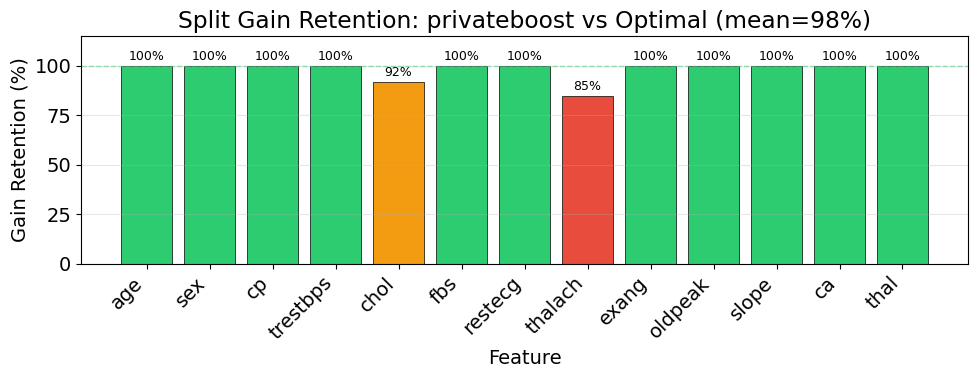

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#2ecc71" if r >= 99 else "#f39c12" if r >= 90 else "#e74c3c" for r in retentions]
bars = ax.bar(HEART_FEATURES, retentions, color=colors, edgecolor="black", linewidth=0.5)
ax.axhline(100, color="#2ecc71", linestyle="--", alpha=0.5, linewidth=1)
ax.set_ylabel("Gain Retention (%)")
ax.set_xlabel("Feature")
ax.set_title(f"Split Gain Retention: privateboost vs Optimal (mean={np.mean(retentions):.0f}%)")
ax.set_ylim(0, 115)
plt.xticks(rotation=45, ha="right")
ax.grid(alpha=0.3, axis="y")

for bar, ret in zip(bars, retentions):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f"{ret:.0f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "gain_retention.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 3: Dropout Resilience

Simulate client dropout at various rates (0%–80%). For each rate, run 5 trials with independent random dropout masks. Report mean accuracy with error bars.

In [11]:
dropout_rates = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
n_trials = 5

dropout_results = {}
for name, data in datasets.items():
    print(f"{name}...")
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    train_idx, test_idx = next(splitter.split(data["X"], data["y"]))
    X_train, y_train = data["X"][train_idx], data["y"][train_idx]
    X_test, y_test = data["X"][test_idx], data["y"][test_idx]

    dropout_results[name] = {rate: [] for rate in dropout_rates}
    for rate in dropout_rates:
        for trial in range(n_trials):
            acc = train_with_dropout(X_train, y_train, X_test, y_test, rate, seed=SEED + trial)
            dropout_results[name][rate].append(acc)
        successes = [a for a in dropout_results[name][rate] if a is not None]
        print(f"  dropout={rate:.0%}: {np.mean(successes):.1%} ± {np.std(successes):.1%} ({len(successes)}/{n_trials} succeeded)")

Heart Disease...


  dropout=0%: 80.0% ± 0.0% (5/5 succeeded)


  dropout=10%: 79.7% ± 2.7% (5/5 succeeded)


  dropout=20%: 77.7% ± 1.3% (5/5 succeeded)


  dropout=30%: 78.7% ± 2.4% (5/5 succeeded)


...

  dropout=40%: 72.1% ± 0.9% (5/5 succeeded)


  dropout=50%: 72.1% ± 1.3% (5/5 succeeded)


  dropout=60%: 70.9% ± 0.5% (5/5 succeeded)


  dropout=70%: 72.3% ± 1.1% (5/5 succeeded)


  dropout=80%: 70.6% ± 1.0% (5/5 succeeded)


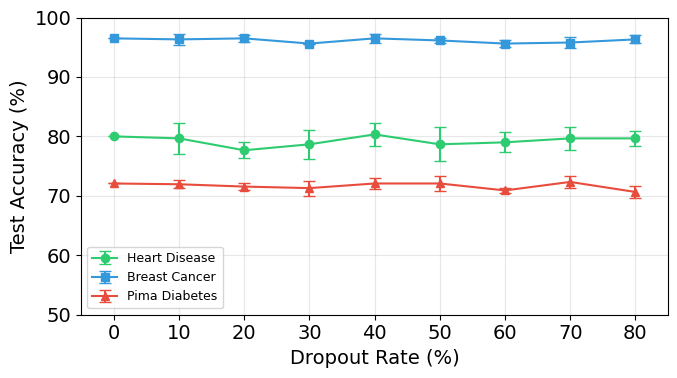

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.array(dropout_rates) * 100
colors = {"Heart Disease": "#2ecc71", "Breast Cancer": "#3498db", "Pima Diabetes": "#e74c3c"}
markers = {"Heart Disease": "o", "Breast Cancer": "s", "Pima Diabetes": "^"}

for name in dropout_results:
    means, stds = [], []
    for rate in dropout_rates:
        successes = [a for a in dropout_results[name][rate] if a is not None]
        means.append(np.mean(successes) if successes else np.nan)
        stds.append(np.std(successes) if successes else 0)
    means, stds = np.array(means), np.array(stds)
    ax.errorbar(x, means * 100, yerr=stds * 100, fmt=f"{markers[name]}-",
                color=colors[name], capsize=4, markersize=6, label=name)

ax.set_xlabel("Dropout Rate (%)")
ax.set_ylabel("Test Accuracy (%)")
ax.legend(loc="lower left", fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(-5, 85)
ax.set_ylim(50, 100)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "dropout_resilience.png", dpi=150, bbox_inches="tight")
plt.show()

## Export results to CSV

In [13]:
# Accuracy results
rows = []
for name, res in learning_results.items():
    row = {"dataset": name}
    for key in ["privateboost", "xgboost_matched", "xgboost_default"]:
        finals = res[key][:, -1]
        row[f"{key}_mean"] = finals.mean()
        row[f"{key}_std"] = finals.std()
    rows.append(row)
df_acc_csv = pd.DataFrame(rows)
df_acc_csv.to_csv(OUTPUT_DIR / "accuracy_results.csv", index=False)

# Dropout results
rows = []
for name, res in dropout_results.items():
    for rate in dropout_rates:
        successes = [a for a in res[rate] if a is not None]
        rows.append({
            "dataset": name, "dropout_rate": rate,
            "mean_accuracy": np.mean(successes) if successes else None,
            "std_accuracy": np.std(successes) if successes else None,
            "success_rate": len(successes) / len(res[rate]),
        })
df_dropout_csv = pd.DataFrame(rows)
df_dropout_csv.to_csv(OUTPUT_DIR / "dropout_results.csv", index=False)

# Gain retention
df_retention = pd.DataFrame({"feature": HEART_FEATURES, "retention_pct": retentions})
df_retention.to_csv(OUTPUT_DIR / "gain_retention.csv", index=False)

print("Saved: accuracy_results.csv, dropout_results.csv, gain_retention.csv")

Saved: accuracy_results.csv, dropout_results.csv, gain_retention.csv


## Communication Cost Analysis

Compute concrete bytes per client per round, with and without path hiding, for each dataset. A Shamir share consists of field elements (8 bytes each) plus a 32-byte commitment hash.

In [14]:
FIELD_ELEMENT_BYTES = 8  # u64
COMMITMENT_BYTES = 32    # SHA-256
SHARE_OVERHEAD = 8       # x-coordinate (u64)

dataset_params = {
    "Heart Disease": {"n_features": 13, "n_clients": 297},
    "Breast Cancer": {"n_features": 30, "n_clients": 569},
    "Pima Diabetes": {"n_features": 8, "n_clients": 768},
}

rows = []
for name, params in dataset_params.items():
    F = params["n_features"]
    c = params["n_clients"]
    n_bins_total = N_BINS + 2  # 10 inner bins + 2 overflow bins

    # Gradient vector size: F features * n_bins_total bins * 2 (gradient + hessian)
    n_values = F * n_bins_total * 2
    share_bytes = n_values * FIELD_ELEMENT_BYTES + SHARE_OVERHEAD + COMMITMENT_BYTES

    # Per client per depth level: one share per shareholder
    bytes_per_client_per_depth = share_bytes * N_SHAREHOLDERS

    # Per client per tree: up to MAX_DEPTH depth levels
    bytes_per_client_per_tree = bytes_per_client_per_depth * MAX_DEPTH

    # Total per tree (all clients)
    bytes_per_tree = bytes_per_client_per_tree * c

    # With path hiding: multiply by 2^d at each depth (1 + 2 + 4 = 7 for depth 3)
    path_hiding_nodes = sum(2**d for d in range(MAX_DEPTH))
    bytes_per_client_per_tree_hidden = share_bytes * N_SHAREHOLDERS * path_hiding_nodes
    bytes_per_tree_hidden = bytes_per_client_per_tree_hidden * c

    # Statistics phase (one-time): 2F values (x, x^2) + 2 (target, target^2)
    stats_values = 2 * F + 2
    stats_share_bytes = stats_values * FIELD_ELEMENT_BYTES + SHARE_OVERHEAD + COMMITMENT_BYTES
    stats_total = stats_share_bytes * N_SHAREHOLDERS * c

    rows.append({
        "Dataset": name,
        "Features": F,
        "Clients": c,
        "Share size": f"{share_bytes:,} B",
        "Per client/depth": f"{bytes_per_client_per_depth / 1024:.1f} KB",
        "Per client/tree": f"{bytes_per_client_per_tree / 1024:.1f} KB",
        "Total/tree": f"{bytes_per_tree / (1024**2):.1f} MB",
        "Total/tree (path hiding)": f"{bytes_per_tree_hidden / (1024**2):.1f} MB",
        "Overhead factor": f"{path_hiding_nodes / MAX_DEPTH:.1f}x",
        "Stats phase (total)": f"{stats_total / (1024**2):.2f} MB",
    })

df_traffic = pd.DataFrame(rows).set_index("Dataset")
df_traffic

,Features,Clients,Share size,Per client/depth,Per client/tree,Total/tree,Total/tree (path hiding),Overhead factor,Stats phase (total)
Dataset,,,,,,,,,
Heart Disease,13,297,"2,536 B",7.4 KB,22.3 KB,6.5 MB,15.1 MB,2.3x,0.22 MB
Breast Cancer,30,569,"5,800 B",17.0 KB,51.0 KB,28.3 MB,66.1 MB,2.3x,0.87 MB
Pima Diabetes,8,768,"1,576 B",4.6 KB,13.9 KB,10.4 MB,24.2 MB,2.3x,0.40 MB


In [15]:
# Summary for paper text
print("Communication cost summary (per tree, all clients):")
print(f"  Depth: {MAX_DEPTH}, Bins: {N_BINS}, Shareholders: {N_SHAREHOLDERS}")
print(f"  Path hiding overhead: {sum(2**d for d in range(MAX_DEPTH))}/{MAX_DEPTH} = {sum(2**d for d in range(MAX_DEPTH)) / MAX_DEPTH:.1f}x")
print()
for name, params in dataset_params.items():
    F = params["n_features"]
    c = params["n_clients"]
    n_values = F * (N_BINS + 2) * 2
    share_bytes = n_values * 8 + 40
    normal = share_bytes * N_SHAREHOLDERS * MAX_DEPTH * c
    hidden = share_bytes * N_SHAREHOLDERS * sum(2**d for d in range(MAX_DEPTH)) * c
    print(f"  {name} ({c} clients, {F} features):")
    print(f"    Standard:     {normal / (1024**2):.1f} MB/tree  ({share_bytes * N_SHAREHOLDERS / 1024:.1f} KB/client/depth)")
    print(f"    Path hiding:  {hidden / (1024**2):.1f} MB/tree  ({sum(2**d for d in range(MAX_DEPTH)) / MAX_DEPTH:.1f}x overhead)")

Communication cost summary (per tree, all clients):
  Depth: 3, Bins: 10, Shareholders: 3
  Path hiding overhead: 7/3 = 2.3x

  Heart Disease (297 clients, 13 features):
    Standard:     6.5 MB/tree  (7.4 KB/client/depth)
    Path hiding:  15.1 MB/tree  (2.3x overhead)
  Breast Cancer (569 clients, 30 features):
    Standard:     28.3 MB/tree  (17.0 KB/client/depth)
    Path hiding:  66.1 MB/tree  (2.3x overhead)
  Pima Diabetes (768 clients, 8 features):
    Standard:     10.4 MB/tree  (4.6 KB/client/depth)
    Path hiding:  24.2 MB/tree  (2.3x overhead)
